# H1.5 — first control experiments on `Bed1D-v0`

**Question (DESIGN §12 H1.5 / Open Question 3):** can gradient-based
optimization choose the valve switch time and regeneration temperature?
The valve flip makes the episode a staircase in the switch time — this
notebook runs the go/no-go comparison between the physical hard valve
and the soft (substep-split) switch, and lands the §6 recipe.

In [1]:
%matplotlib inline

import sys
from pathlib import Path
for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / 'harness' / '__init__.py').exists():
        sys.path.insert(0, str(_p))
        break

import jax
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_platforms", "cpu")

from harness.control import demo_problem, switch_time_sweep, gradient_check
from harness.backends import GradientBackend, SearchBackend
from harness.envs.base import Objective

BOUNDS = (60.0, 500.0)
grid = np.arange(60.0, 501.0, 40.0)

## 1 — the headline plot: steady-periodic COP/SCP vs switch time

The classic adsorption-chiller trade-off: SCP peaks where swing
completion balances the 1/t_cycle dilution; COP keeps rising with cycle
time (deeper swings reject less sensible heat per unit cooling).

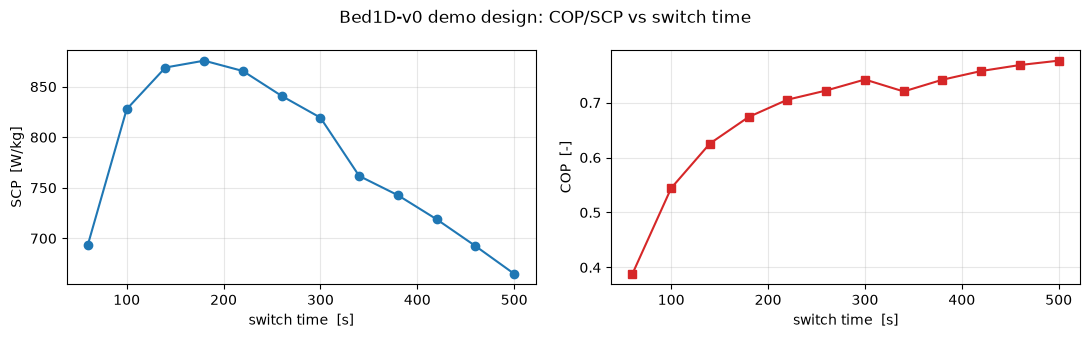

In [2]:
hard = demo_problem(t_switch_bounds=BOUNDS, soft_switch=False, n_steps=20008)
soft = demo_problem(t_switch_bounds=BOUNDS, soft_switch=True,  n_steps=20008)

rows_hard = switch_time_sweep(hard, grid)
rows_soft = switch_time_sweep(soft, grid)   # soft ≈ hard: the split only
                                            # refines the boundary substep
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
t = [r["t_switch_s"] for r in rows_soft]
ax[0].plot(t, [r["SCP_W_kg"] for r in rows_soft], "o-", label="SCP")
ax[0].set_ylabel("SCP  [W/kg]")
ax[1].plot(t, [r["COP"] for r in rows_soft], "s-", color="tab:red", label="COP")
ax[1].set_ylabel("COP  [-]")
for a in ax:
    a.set_xlabel("switch time  [s]")
    a.grid(alpha=0.3)
fig.suptitle("Bed1D-v0 demo design: COP/SCP vs switch time")
fig.tight_layout()

## 2 — Open Question 3: hard vs soft gradients

With the hard valve the flips quantize to physics substeps: between
regroupings the metric is exactly flat in the switch time, so
`∂SCP/∂t_switch` collapses to the trivial `−SCP/t` denominator term —
nonzero, gradient-ascent-visible, and blind to the physics (it pushes
the switch time to a bound). Soft switching splits boundary substeps at
the valve event, restoring the true physical slope.

In [3]:
probes = [(200.037, 75.0), (300.037, 75.0)]
gaps = {}
for tag, prob in (("hard", hard), ("soft", soft)):
    rows = gradient_check(prob, probes, h_switch=5e-4, h_t_f=0.05)
    gaps[tag] = rows
    for r in rows:
        print(f"{tag:4s} t_switch={r['t_switch_s']:.1f}: "
              f"grad_ad={r['grad_ad'][0]:+8.3f}  grad_fd={r['grad_fd'][0]:+8.3f}  "
              f"rel_err={r['rel_err']:.1e}")
    scp = prob.evaluate({"t_switch_s": probes[0][0]})['SCP_W_kg']
    print(f"     (blind-term -SCP/t_switch = {-scp/probes[0][0]:+.3f})")

hard t_switch=200.0: grad_ad=  -4.365  grad_fd=-130.458  rel_err=9.7e-01
hard t_switch=300.0: grad_ad=  -2.733  grad_fd=  -2.733  rel_err=3.2e-07


     (blind-term -SCP/t_switch = -4.365)


soft t_switch=200.0: grad_ad= +23.591  grad_fd=+1228.558  rel_err=9.8e-01
soft t_switch=300.0: grad_ad= +13.380  grad_fd= +13.380  rel_err=3.2e-07


     (blind-term -SCP/t_switch = -4.363)


In [4]:
hard_opt = GradientBackend().solve(hard, Objective.single("SCP_W_kg"),
                                   n_starts=1, n_steps=25, step_size=0.02, seed=0)
print("hard-valve 'optimum':", {k: round(v, 1) for k, v in hard_opt.best_design.items()},
      "SCP", round(hard_opt.best_metrics["SCP_W_kg"], 1),
      " <- ran to the t_switch lower bound: the blind gradient at work")

hard-valve 'optimum': {'t_f_des_c': 85.0, 't_switch_s': 60.0} SCP 1032.8  <- ran to the t_switch lower bound: the blind gradient at work


## 3 — optimizing both controls with real gradients (soft switch)

Adam climbs from the default controls (120 s, 75 °C) toward the sweep
optimum; CMA-ES pins the global basin. The residual Adam gap (ridge
drift at fixed learning rate) is the recorded motivation for the §6
hybrid: **search on switch times, grad on smooth controls**.

In [5]:
grad_res = GradientBackend().solve(soft, Objective.single("SCP_W_kg"),
                                   n_starts=1, n_steps=60, step_size=0.005, seed=0)
cma_res = SearchBackend().solve(soft, Objective.single("SCP_W_kg"),
                                method="cmaes", budget=50, seed=0)
print("Adam :", {k: round(v, 1) for k, v in grad_res.best_design.items()},
      "SCP", round(grad_res.best_objective, 1))
print("CMA  :", {k: round(v, 1) for k, v in cma_res.best_design.items()},
      "SCP", round(cma_res.best_objective, 1))
best_sweep = max(r["SCP_W_kg"] for r in rows_soft)
print(f"sweep max on the 40 s grid: {best_sweep:.1f} W/kg")

Adam : {'t_f_des_c': 82.1, 't_switch_s': 228.4} SCP 1082.3
CMA  : {'t_f_des_c': 85.0, 't_switch_s': 133.4} SCP 1193.7
sweep max on the 40 s grid: 875.7 W/kg


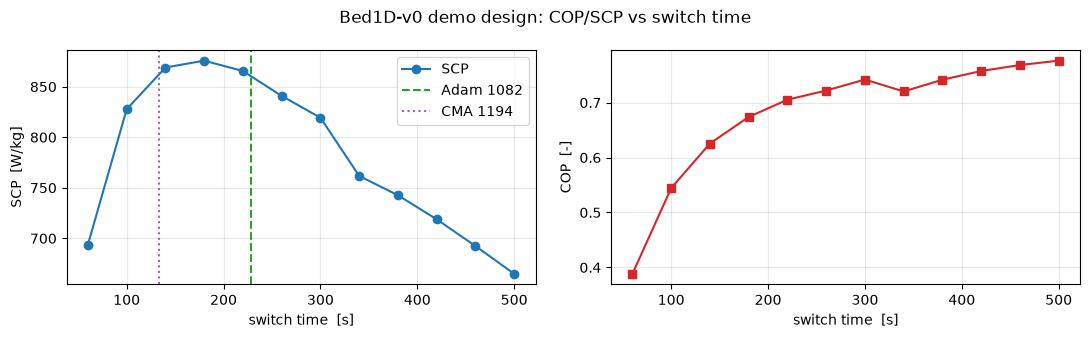

In [6]:
ax[0].axvline(grad_res.best_design["t_switch_s"], ls="--", color="tab:green",
              label=f"Adam {grad_res.best_objective:.0f}")
ax[0].axvline(cma_res.best_design["t_switch_s"], ls=":", color="tab:purple",
              label=f"CMA {cma_res.best_objective:.0f}")
ax[0].legend()
fig

## 4 — decision (Open Question 3, recorded in DESIGN §13.3)

| option | gradients | optimization | verdict |
|---|---|---|---|
| hard switch | staircase: only the blind `−SCP/t` term | runs to bounds | **no-go for grad** |
| soft switch (substep split) | true local slopes (V5: FD match < 1e-3) | Adam climbs near-optimum; CMA global | **go** |

**Recipe going forward:** soft switching for any gradient-based schedule
work; switch times via `search` (or multi-start grad); `grad` for the
smooth controls (`T_f,des`, design parameters). The hard valve stays the
default physics — the split is a diagnostic/optimization view whose
boundary refinement changes episode metrics only at the substep scale.